# Week 2: Loan Approval Prediction - AnalystLab Africa Consulting

## Part 2: Data Inspection

In [ ]:
# Import necessary libraries
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Visualization Color Palette
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": "#B0B0B0", "axes.labelcolor": "#333333",
    "text.color": "#333333", "xtick.color": "#333333", "ytick.color": "#333333",
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
NAVY, BLUE, RED, LBLUE, GOLD = "#1F3864", "#2E74B5", "#C0504D", "#9DC3E6", "#E1A100"

In [ ]:
# Load the dataset
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv') 
df.head(5) # Display the first 5 rows of the dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info() # Examine the dataset structure

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [ ]:
print('Dataset shape:', df.shape) # Identify rows and columns

Dataset shape: (614, 13)


In [ ]:
# Data types, missing values,and  duplicate records
data_types = pd.DataFrame({'Data Type': df.dtypes,
                           'Non-Null Count': df.notnull().sum(),
                           'Missing Values': df.isnull().sum(),
                           'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
                           'Duplicate Records': df.duplicated().sum(),
                        })

data_types

,Data Type,Non-Null Count,Missing Values,Missing %,Duplicate Records
Loan_ID,str,614,0,0.00,0
Gender,str,601,13,2.12,0
Married,str,611,3,0.49,0
Dependents,str,599,15,2.44,0
Education,str,614,0,0.00,0
Self_Employed,str,582,32,5.21,0
ApplicantIncome,int64,614,0,0.00,0
CoapplicantIncome,float64,614,0,0.00,0
LoanAmount,float64,592,22,3.58,0
Loan_Amount_Term,float64,600,14,2.28,0


In [ ]:
# Numerical Summary Statistics
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# Categorical Summary Statistics
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
# Overall Data Inspection Summary
inspection_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Duplicate Records': df.duplicated().sum(),
    'Unique Values': df.nunique(),
    'Top Value': df.mode().iloc[0],
    'Top Value Count': df.apply(lambda x: x.value_counts().max()),
    'Top Value %': (df.apply(lambda x: x.value_counts().max()) / len(df) * 100).round(2)
})
inspection_summary

,Data Type,Non-Null Count,Missing Values,Missing %,Duplicate Records,Unique Values,Top Value,Top Value Count,Top Value %
Loan_ID,str,614,0,0.00,0,614,LP001002,1,0.16
Gender,str,601,13,2.12,0,2,Male,489,79.64
Married,str,611,3,0.49,0,2,Yes,398,64.82
Dependents,str,599,15,2.44,0,4,0,345,56.19
Education,str,614,0,0.00,0,2,Graduate,480,78.18
Self_Employed,str,582,32,5.21,0,2,No,500,81.43
ApplicantIncome,int64,614,0,0.00,0,505,2500.0,9,1.47
CoapplicantIncome,float64,614,0,0.00,0,287,0.0,273,44.46
LoanAmount,float64,592,22,3.58,0,203,120.0,20,3.26
Loan_Amount_Term,float64,600,14,2.28,0,10,360.0,512,83.39


### Interpretation / Conclusion

The initial inspection shows that the Loan Prediction dataset contains **614 rows and 13 columns**, including both numerical and categorical variables. The dataset contains information about applicants' demographic characteristics, income, loan details, credit history, property area, and loan approval status.

Several variables contain missing values, particularly **Credit_History, Self_Employed, Dependents, Gender, LoanAmount, and Loan_Amount_Term**. These missing values will need to be handled appropriately before machine learning. The dataset contains **no duplicate records**, which means no duplicate rows need to be removed at this stage.

The dataset also contains a mixture of **categorical and numerical variables**. Categorical variables will require appropriate encoding, while numerical variables will need to be examined for scale differences and potential outliers. `Loan_ID` appears to be an identifier rather than a meaningful predictive feature and should therefore be considered for removal.

Overall, the dataset requires further preprocessing before it can be used for machine learning. The next steps will involve **handling missing values, encoding categorical variables, detecting outliers, examining correlations and redundancy, scaling numerical features where necessary, and selecting the most relevant predictors**. After these steps, the dataset should be suitable for developing a loan approval prediction model.

# Part 3 – Feature Engineering & Data Preprocessing
 
Transforms the raw Loan Prediction dataset into a machine-learning-ready
dataset: cleaning, feature engineering, encoding, scaling, and outlier
handling.

### Data Cleaning 

#### 1. Missing Values
* For categorical variables, we use the mode because these variables contain categories rather than numerical measurements.
* For numerical variables, we  use the median.

In [ ]:
df_copy = df.copy()
df_copy.head(5) # Display the first 5 rows of the copied dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
def wrangle(df):
    """Clean loan data in one pass and return a cleaned copy."""
    df_copy = df.copy()
    
    # Standardize Dependents values
    df_copy['Dependents'] = df_copy['Dependents'].replace('3+', '3')

    # Categorical mode imputation
    # Loop through columns with missing values and fill them with their respective mode
    for col in ['Gender', 'Married', 'Self_Employed']:
        col_mode = df_copy[col].mode()[0]
        df_copy[col] = df_copy[col].fillna(col_mode)

    # Specific column imputations
    df_copy['Dependents'] = df_copy['Dependents'].fillna(df_copy['Dependents'].mode()[0])
    df_copy['Credit_History'] = df_copy['Credit_History'].fillna(df_copy['Credit_History'].mode()[0])
    df_copy['LoanAmount'] = df_copy['LoanAmount'].fillna(df_copy['LoanAmount'].median())
    df_copy['Loan_Amount_Term'] = df_copy['Loan_Amount_Term'].fillna(df_copy['Loan_Amount_Term'].mode()[0])

    # Final type corrections
    df_copy['Dependents'] = df_copy['Dependents'].astype(int)
    df_copy['Credit_History'] = df_copy['Credit_History'].astype(int)
    df_copy['Loan_Amount_Term'] = df_copy['Loan_Amount_Term'].astype(int)

    # Optional cleanup
    df_copy = df_copy.drop_duplicates()

    # Rename columns for clarity and consistency, snake_case is preferred for programming 
    # and data analysis tasks.
    df_copy = df_copy.rename(columns={
        'ApplicantIncome': 'Applicant_Income',
        'CoapplicantIncome': 'Coapplicant_Income',
        'LoanAmount': 'Loan_Amount'
    })

    return df_copy


# Clean all at once
df_clean = wrangle(df)

print(f"Rows, Columns: {df_clean.shape}")
print(f"Total missing cells remaining: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows remaining: {df_clean.duplicated().sum()}")
df_clean.head()

Rows, Columns: (614, 13)
Total missing cells remaining: 0
Duplicate rows remaining: 0


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y


In [ ]:
df_clean.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [ ]:
# EXPORT CLEANED DATASET (.CSV)
os.makedirs("data/processed", exist_ok=True)
output_path = "data/processed/loan_prediction_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print("=== CLEANED DATASET SUCCESSFULLY EXPORTED ===")
print(f"File Location: {output_path}")
print(f"Dataset Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
df_clean.head()

=== CLEANED DATASET SUCCESSFULLY EXPORTED ===
File Location: data/processed/loan_prediction_cleaned.csv
Dataset Shape: 614 rows, 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y


## Feature Engineering
This involves creating meaningful variables from existing data that may help the model identify patterns.

In [ ]:
# Remove irrelevant features
df_clean = df_clean.drop(columns=["Loan_ID"])
print("[Removed] Loan_ID: a unique identifier with no predictive relationship to loan "
    "approval. Keeping it risks the model treating it as a spurious signal, and it adds no "
    "business-explainable value.")
 

[Removed] Loan_ID: a unique identifier with no predictive relationship to loan approval. Keeping it risks the model treating it as a spurious signal, and it adds no business-explainable value.


In [ ]:
# Create new features 
# 1. Create Total Income: An applicant's financial capacity is 
# better represented by considering both their income and their coapplicant's income.
df_clean['Total_Income'] = df_clean['Applicant_Income'] + df_clean['Coapplicant_Income']

# Check it:
df_clean[['Applicant_Income', 'Coapplicant_Income', 'Total_Income']].head()
# Why?
# TotalIncome combines the financial contributions of the applicant and 
# coapplicant into a single measure. This may provide a more useful representation 
# of household income for predicting loan approval.

,Applicant_Income,Coapplicant_Income,Total_Income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


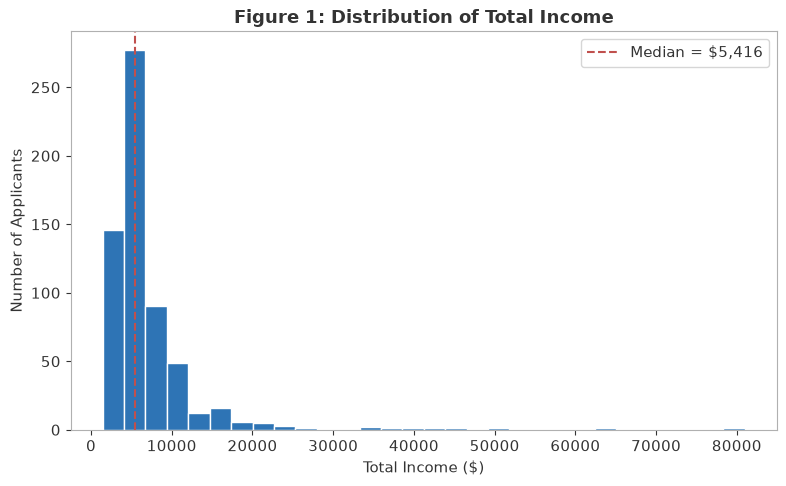

In [ ]:
# 1. HISTOGRAM - Total Income distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean["Total_Income"], bins=30, color=BLUE, edgecolor="white")
ax.set_title("Figure 1: Distribution of Total Income")
ax.set_xlabel("Total Income ($)")
ax.set_ylabel("Number of Applicants")
ax.axvline(df_clean["Total_Income"].median(), color=RED, linestyle="--", linewidth=1.5,
           label=f"Median = ${df_clean['Total_Income'].median():,.0f}")
ax.legend()
fig.tight_layout()
fig.savefig("charts/01_histogram_total_income.png", dpi=170, bbox_inches="tight")
plt.show()


In [ ]:
# 2. Monthly Debt Repayment Estimate (LoanAmount is reported in thousands)
df_clean["Monthly_Repayment"] = (df_clean["Loan_Amount"] * 1000) / df_clean["Loan_Amount_Term"]
print("  Monthly_Repayment = (LoanAmount * 1000) / Loan_Amount_Term")
print("    Reason: an approximate monthly instalment estimate, which is a more direct measure "
    "of monthly repayment burden than loan amount or term alone.")

# 3. Create Balance Income: This feature represents the income an applicant has left 
# after covering the estimated loan instalment, providing insight into their real repayment capacity.
df_clean["Balance_Income"] = df_clean["Total_Income"] - df_clean["Monthly_Repayment"]
print("  Balance_Income = Total_Income - Monthly_Repayment")
print("    Reason: proxies the income an applicant has left after covering the estimated loan "
    "instalment, which is intuitively closer to real repayment capacity than raw income.")

# 4. Create Loan-to-Income Ratio: This ratio captures the relationship between the loan amount
# and the applicant's total income, providing insight into the applicant's ability to manage debt relative to their income.
df_clean["Loan_Income_Ratio"] = (df_clean["Loan_Amount"] * 1000) / df_clean["Total_Income"]
print("  Loan_Income_Ratio = (Loan_Amount * 1000) / Total_Income")
print("    Reason: a debt-to-income style ratio; two applicants with the same loan amount but "
    "very different incomes carry very different risk, which this ratio captures directly.")
 
print(f"\nShape after feature engineering: {df_clean.shape}")

  Monthly_Repayment = (LoanAmount * 1000) / Loan_Amount_Term
    Reason: an approximate monthly instalment estimate, which is a more direct measure of monthly repayment burden than loan amount or term alone.
  Balance_Income = Total_Income - Monthly_Repayment
    Reason: proxies the income an applicant has left after covering the estimated loan instalment, which is intuitively closer to real repayment capacity than raw income.
  Loan_Income_Ratio = (Loan_Amount * 1000) / Total_Income
    Reason: a debt-to-income style ratio; two applicants with the same loan amount but very different incomes carry very different risk, which this ratio captures directly.

Shape after feature engineering: (614, 16)


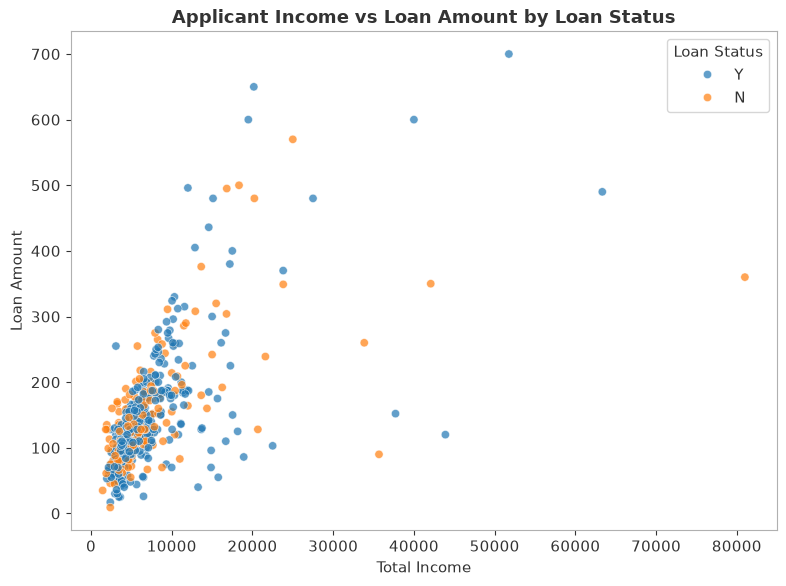

In [ ]:
# Total Income vs Loan Amount
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x='Total_Income',
    y='Loan_Amount',
    hue='Loan_Status',
    alpha=0.7
)

plt.title('Applicant Income vs Loan Amount by Loan Status')
plt.xlabel('Total Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')

plt.tight_layout()
plt.savefig("charts/scatterplot_total_income_vs_loan.png", dpi=300, bbox_inches="tight")

plt.show()

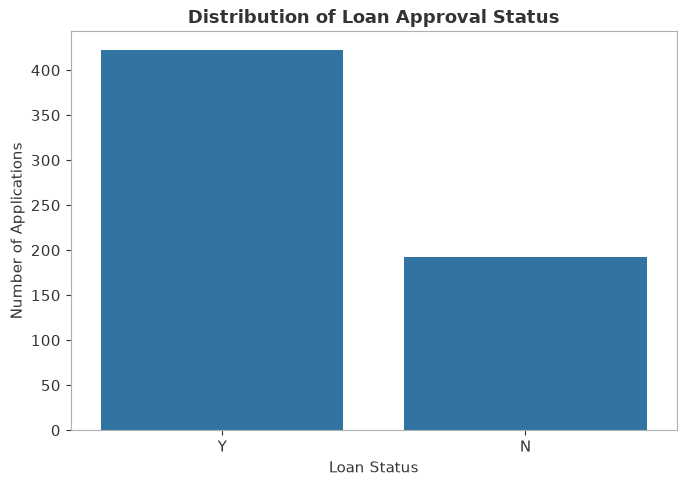

In [ ]:
# Loan Approval Status Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='Loan_Status'
)

plt.title('Distribution of Loan Approval Status')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')

plt.tight_layout()
plt.savefig("charts/loan_approval_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df["Loan_Status"].value_counts()
# df["Loan_Status"].value_counts(normalize=True) * 100

## 3. OUTLIER DETECTION & HANDLING

In [ ]:
print("3. OUTLIER DETECTION & HANDLING")
print("=" * 80)
 
continuous_cols = ["Applicant_Income", "Coapplicant_Income", "Loan_Amount",
                    "Total_Income", "Monthly_Repayment", "Balance_Income", "Loan_Income_Ratio"]
 
print("\n[Method] IQR (Interquartile Range) method chosen over Z-score.")
print("  Reason: these variables are heavily right-skewed (e.g. Applicant_Income skew=6.54), and "
    "Z-score assumes an approximately normal distribution -- on skewed data it under-flags high-end "
    "outliers and can over-flag values near the (compressed) mean. The IQR method makes no "
    "normality assumption and is robust to skew, making it the more appropriate choice here. "
    "Boxplots were used to visually confirm the presence and scale of outliers before and after treatment.")
 
print("\n[Treatment] Capping (winsorizing) at the IQR fences, not row removal.")
print("  Reason: the dataset is small (614 rows). Deleting every outlier row would discard real, "
    "legitimate high-income or high-loan-amount applicants and shrink an already limited training "
    "set. Capping preserves every row while limiting the influence of extreme values on scaling "
    "and downstream model training.")
 
def iqr_cap(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    capped = series.clip(lower=lower, upper=upper)
    return capped, n_outliers, lower, upper
 
print("\n[Outliers detected and capped, per column]")
for col in continuous_cols:
    capped, n_outliers, lower, upper = iqr_cap(df_clean[col])
    df_clean[col] = capped
    print(f"  {col}: {n_outliers} outliers capped to range [{lower:.1f}, {upper:.1f}]")

3. OUTLIER DETECTION & HANDLING

[Method] IQR (Interquartile Range) method chosen over Z-score.
  Reason: these variables are heavily right-skewed (e.g. Applicant_Income skew=6.54), and Z-score assumes an approximately normal distribution -- on skewed data it under-flags high-end outliers and can over-flag values near the (compressed) mean. The IQR method makes no normality assumption and is robust to skew, making it the more appropriate choice here. Boxplots were used to visually confirm the presence and scale of outliers before and after treatment.

[Treatment] Capping (winsorizing) at the IQR fences, not row removal.
  Reason: the dataset is small (614 rows). Deleting every outlier row would discard real, legitimate high-income or high-loan-amount applicants and shrink an already limited training set. Capping preserves every row while limiting the influence of extreme values on scaling and downstream model training.

[Outliers detected and capped, per column]
  Applicant_Income: 50 

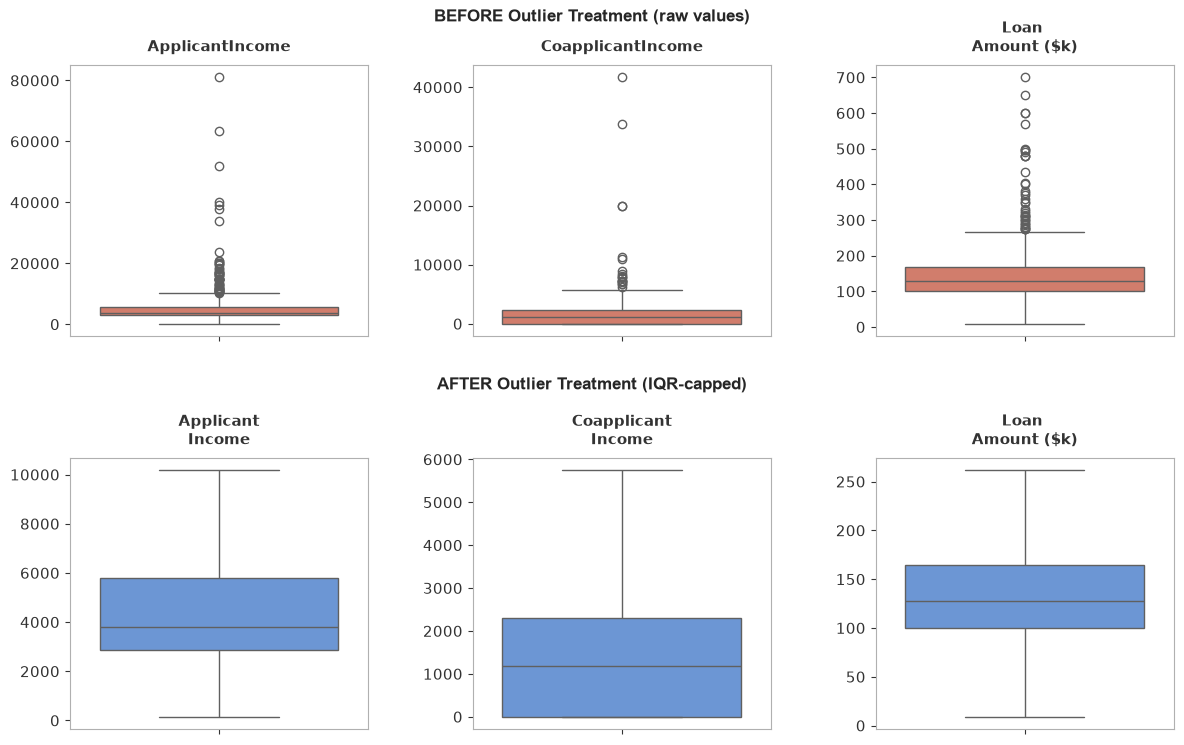

In [ ]:
# 1. Setup the figure layout
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Select the three primary columns of interest for visualization.
target_cols_d = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# 2. Plot BEFORE Treatment (Row 0)
for i, col in enumerate(target_cols_d):
    ax = axes[0, i]
    # Make sure to pass your raw un-capped data copy here
    sns.boxplot(y=df_copy[col], ax=ax, color="#E2725B")  # Coral/Orange color
    
    # Adjust titles for specific formatting
    title_text = "Loan \nAmount ($k)" if col == "LoanAmount" else col.replace("_", "\n")
    ax.set_title(title_text, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel("")
    ax.set_xlabel("")

# 3. Plot AFTER Treatment (Row 1)
# Select the three primary columns of interest for visualization after cleaning.
target_cols_dc = ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount']

for i, col in enumerate(target_cols_dc):
    ax = axes[1, i]
    # Pass your capped data here
    sns.boxplot(y=df_clean[col], ax=ax, color="#5B92E5")  # Soft Blue color
    
    title_text = "Loan \nAmount ($k)" if col == "Loan_Amount" else col.replace("_", "\n")
    ax.set_title(title_text, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel("")
    ax.set_xlabel("")

# 4. Add Section Headers and Polish Layout
plt.tight_layout()
plt.savefig("charts/boxplot_outlier_treatment_comparison.png", dpi=300, bbox_inches="tight")


# Positioning subtitles perfectly above each row block
fig.text(0.5, 0.94, "BEFORE Outlier Treatment (raw values)", 
         ha='center', va='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.48, "AFTER Outlier Treatment (IQR-capped)", 
         ha='center', va='center', fontsize=12, fontweight='bold')

# Adjust spacing to make room for text banners
plt.subplots_adjust(top=0.88, bottom=0.05, hspace=0.45, wspace=0.35)
plt.show()


## 4. Correlation Check (Redundant Features)

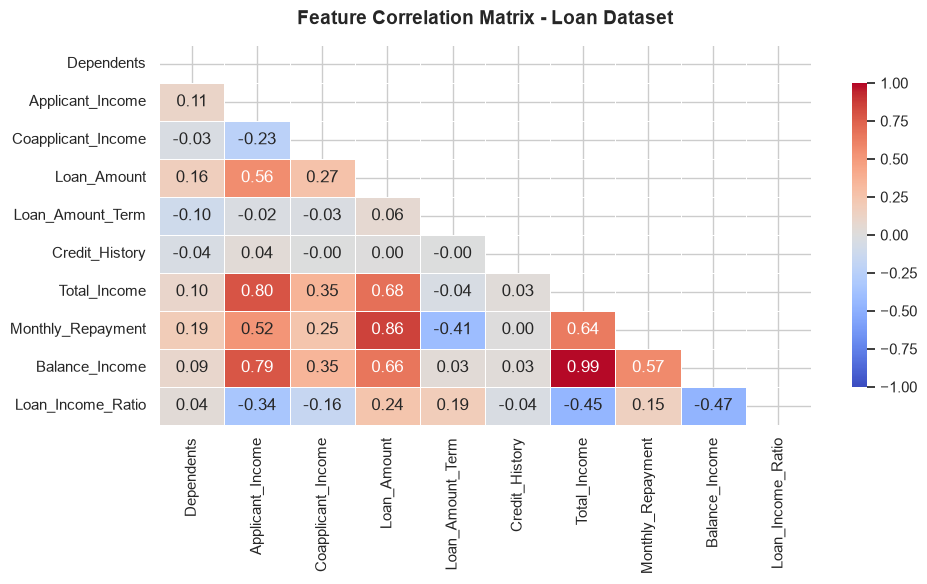

=== HIGHLY CORRELATED / REDUNDANT FEATURE PAIRS (|r| > 0.75) ===
• Total_Income <---> Applicant_Income: Correlation = 0.80
• Monthly_Repayment <---> Loan_Amount: Correlation = 0.86
• Balance_Income <---> Applicant_Income: Correlation = 0.79
• Balance_Income <---> Total_Income: Correlation = 0.99


In [ ]:
# Ensure charts directory exists
os.makedirs("charts", exist_ok=True)

# CORRELATION ANALYSIS (REDUNDANT FEATURES)
# Filter for numeric columns
numeric_df = df_clean.select_dtypes(include=[np.number])

# Compute Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Plot Correlation Heatmap
plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    mask=mask,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Feature Correlation Matrix - Loan Dataset",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig("charts/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Detect highly correlated feature pairs (|r| > 0.75 excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            val = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, val))

print("=== HIGHLY CORRELATED / REDUNDANT FEATURE PAIRS (|r| > 0.75) ===")
if high_corr_pairs:
    for col1, col2, val in high_corr_pairs:
        print(f"• {col1} <---> {col2}: Correlation = {val:.2f}")
else:
    print("No severe multicollinearity detected (|r| <= 0.75).")

In [ ]:
# DROPPING HIGHLY COLLINEAR / REDUNDANT FEATURES
# Drop raw collinear inputs to prevent variance inflation (VIF) in ML models
columns_to_drop = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Balance_Income",
]

# Drop only columns that exist in the dataframe
df_clean.drop(
    columns=[col for col in columns_to_drop if col in df_clean.columns],
    inplace=True,
)

print("DROPPED REDUNDANT FEATURES")
print(f"Remaining Columns ({len(df_clean.columns)}):", list(df_clean.columns))

DROPPED REDUNDANT FEATURES
Remaining Columns (12): ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'Total_Income', 'Monthly_Repayment', 'Loan_Income_Ratio']


## 5. FEATURE ENCODING

In [ ]:
# 5. CATEGORICAL ENCODING
# Binary Mapping for Target Variable
df_clean["Loan_Status"] = df_clean["Loan_Status"].map({"Y": 1, "N": 0})

# Binary Categorical Features Mapping
binary_cols = {
    "Gender": {"Male": 1, "Female": 0},
    "Married": {"Yes": 1, "No": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
    "Education": {"Graduate": 1, "Not Graduate": 0}
}
for col, mapping in binary_cols.items():
    df_clean[col] = df_clean[col].map(mapping)

# One-Hot Encoding for Nominal Multi-Class Variables (Property_Area)
df_clean = pd.get_dummies(df_clean, columns=["Property_Area"], drop_first=True, dtype=int)


The 'Rural' category did not actually disappear from our data, it was intentionally hidden because you used the argument *drop_first=True*.
This is a standard practice in machine learning called dummy variable encoding to prevent redundant information.
What is happening under the hood:
When you have three categories ('Rural', 'Semiurban', 'Urban'), you only need two columns to represent them mathematically:

* If a row is Semiurban, the Semiurban column is 1.
* If a row is Urban, the Urban column is 1.
* If a row is Rural, both columns become 0.The computer still perfectly understands where the 'Rural' houses are. It knows that any row with two zeros (0 and 0) is automatically a Rural property.

In [ ]:
# 6. FEATURE SCALING & NORMALIZATION
# Identify continuous numerical features requiring scaling
scaling_cols = [
    "Total_Income",
    "Monthly_Repayment",
    "Loan_Amount_Term",
    "Loan_Income_Ratio"
]

scaler = RobustScaler()  # Using RobustScaler to mitigate the influence of any remaining outliers
df_clean[scaling_cols] = scaler.fit_transform(df_clean[scaling_cols])


In [ ]:
# 7. FEATURE SELECTION SUMMARY
print("7. FINAL FEATURE SET")
print("=" * 80)
print(f"\nFinal shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print("Final columns:")
for c in df_clean.columns:
    print(f"  - {c}")

7. FINAL FEATURE SET

Final shape: 614 rows, 13 columns
Final columns:
  - Gender
  - Married
  - Dependents
  - Education
  - Self_Employed
  - Loan_Amount_Term
  - Credit_History
  - Loan_Status
  - Total_Income
  - Monthly_Repayment
  - Loan_Income_Ratio
  - Property_Area_Semiurban
  - Property_Area_Urban


In [ ]:
# 7. EXPORT ML-READY DATASET
df_clean.to_csv("loan_prediction_ml_ready.csv", index=False)
print("PREPROCESSING COMPLETE ")
print(f"Final ML-Ready Dataset Shape: {df_clean.shape}")
df_clean.head()

PREPROCESSING COMPLETE 
Final ML-Ready Dataset Shape: (614, 13)


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Monthly_Repayment,Loan_Income_Ratio,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,0.0,1,1,0.128883,-0.025641,-0.251204,0,1
1,1,1,1,1,0,0.0,1,0,0.200998,-0.025641,-0.348488,0,0
2,1,1,0,1,1,0.0,1,1,-0.720107,-0.820513,-0.238234,0,1
3,1,1,0,0,0,0.0,1,1,-0.141697,-0.128205,0.017608,0,1
4,1,0,0,1,0,0.0,1,1,0.173881,0.141026,-0.070401,0,1


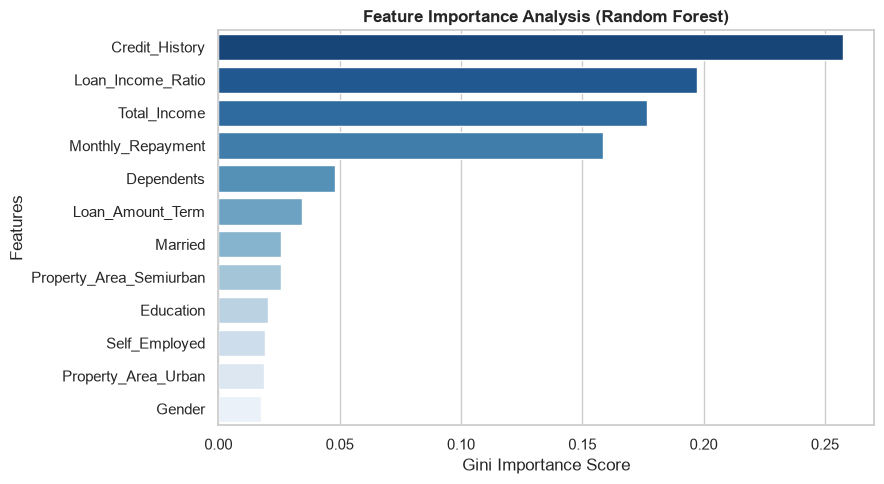

In [ ]:
# Feature Importance Analysis using Random Forest
# Separate predictors (X) and target variable (y)
X = df_clean.drop(columns=["Loan_Status"])
y = df_clean["Loan_Status"]

# 1. FEATURE IMPORTANCE ANALYSIS (RANDOM FOREST)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(
    x=importances.values, y=importances.index, palette="Blues_r", hue=importances.index, legend=False
)
plt.title(
    "Feature Importance Analysis (Random Forest)", fontsize=12, fontweight="bold"
)
plt.xlabel("Gini Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()